# 4.5 The Three Pillars of Model Development

A working deep learning model rests on three pillars:

1. **Training data**: its quality, diversity, balance among classes, and noise level.
2. **Architecture**: the family of functions the network can represent, and how many parameters it spends doing so.
3. **Training strategy**: the loss function, the optimizer, the learning rate, the batch size, the stopping rule.

Most model failures trace back to exactly one of these pillars, and each pillar fails with a recognizable signature. This notebook is a hands-on lab: we hold one classification task fixed and break each pillar on purpose, so you learn to read the signatures before you meet them in your project data.

The lab uses small multi-layer perceptrons on a synthetic lithology table. Every experiment runs in seconds on a laptop CPU. You can raise sample counts and epochs on your own machine; the lessons do not change.

## 1. One task, one small model

The task for the whole lab: classify rock samples into three lithology classes (granite, basalt, andesite) from 9 geochemical and physical features (major-element oxides in wt%, density in g/cm$^3$, magnetic susceptibility in SI units). The data comes from `mlgeo_synth.geochem_table`, a generator that plants realistic correlations between oxides through a latent differentiation index. Because the generator is ours, we control the exact amount of label noise, class imbalance, and sensor noise — the knobs real data never gives us.

One adjustment makes the lab realistic: the generator's raw tables are almost perfectly separable, which no field instrument delivers. Every dataset in this lab therefore carries a fixed measurement-noise floor of one standard deviation per feature, applied to training, validation, and test alike. The corruption experiments in Section 3 add specific defects on top of that floor.

### 1.1 Train, validation, and test sets

Before any experiment, the data is split three ways:

* **Training set**: used to fit the model. It should be the largest portion, typically 60-80% of the data, and as diverse and balanced as the problem allows.
* **Validation set**: used during training to tune hyperparameters and detect overfitting. It gives an estimate of performance on unseen data while decisions are still being made. Typically 10-20%.
* **Test set**: used once, at the end, to report generalization. It must stay completely separate from every decision made during model development. If information from the test set influences training or model selection, the reported performance is inflated. This failure is called **data leakage**, and it appears again in Section 5.

One detail matters for this lab: our **test set is always clean** (no label noise, no defects beyond the shared measurement-noise floor), even when we corrupt the training data on purpose. That is how we measure what corruption costs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, recall_score

import mlgeo_synth

# Device-agnostic setup. The models in this lab are tiny (a few thousand
# parameters), and for models this small the CPU is faster than an
# accelerator because kernel-launch overhead dominates. We detect the
# accelerator to show the pattern, then deliberately train on CPU.
detected = torch.device("cuda" if torch.cuda.is_available()
                        else "mps" if torch.backends.mps.is_available()
                        else "cpu")
device = torch.device("cpu")
print(f"accelerator detected: {detected}; using: {device}")

torch.manual_seed(0)
np.random.seed(0)

accelerator detected: mps; using: cpu


In [2]:
df = mlgeo_synth.geochem_table(n=3000, label_noise=0.0, seed=0)
print(df.shape)
df.head()

(3000, 10)


,SIO2,AL2O3,FEO,MGO,CAO,NA2O,K2O,density_g_cm3,mag_susc_si,label
0,48.271072,14.550932,9.584487,7.786032,11.408379,2.258560,0.812292,2.964359,0.001658,basalt
1,72.178440,14.659499,2.189115,1.033966,2.353944,4.054576,4.720737,2.667887,0.000087,granite
2,73.667158,13.452573,1.191274,0.140795,1.781264,4.588104,5.456854,2.651066,0.000108,granite
3,69.915112,14.344166,4.565303,2.014665,2.891233,3.588710,2.962119,2.647545,0.000129,granite
4,50.691400,15.028301,7.642222,6.779043,10.832978,2.687062,0.742804,3.009791,0.001025,basalt


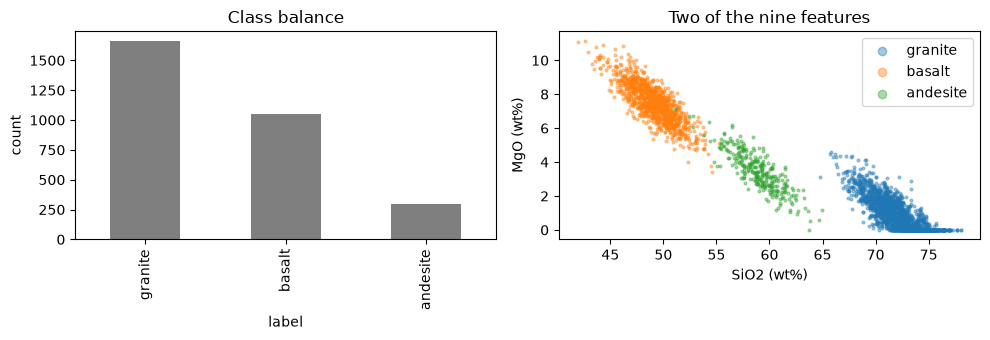

In [3]:
CLASSES = ["granite", "basalt", "andesite"]
FEATURES = [c for c in df.columns if c != "label"]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
df["label"].value_counts().loc[CLASSES].plot.bar(ax=ax[0], color="tab:gray")
ax[0].set_ylabel("count"); ax[0].set_title("Class balance")
for c in CLASSES:
    sub = df[df["label"] == c]
    ax[1].scatter(sub["SIO2"], sub["MGO"], s=4, alpha=0.4, label=c)
ax[1].set_xlabel("SiO2 (wt%)"); ax[1].set_ylabel("MgO (wt%)")
ax[1].set_title("Two of the nine features"); ax[1].legend(markerscale=3)
plt.tight_layout()

The classes are imbalanced by construction (andesite is rare) and they overlap in feature space. Both properties are typical of geochemical classification problems.

### 1.2 Lab helpers

Three pieces of code carry the whole lab: a data function with corruption knobs, a configurable MLP, and a training loop that records learning curves. Read them once, carefully; every experiment below is a few lines that call them.

In [4]:
def table_to_xy(frame):
    X = frame[FEATURES].to_numpy(dtype=np.float32)
    y = frame["label"].map({c: i for i, c in enumerate(CLASSES)}).to_numpy()
    return X, y.astype(np.int64)


def make_data(n_train=3000, label_noise=0.0, minority_keep=1.0,
              feature_noise=0.0, base_noise=1.0, seed=0):
    '''Train/val splits with optional corruption; test set always clean.

    label_noise   : fraction of flipped labels in train+val
    minority_keep : fraction of andesite (minority) samples kept in train+val
    feature_noise : std of EXTRA Gaussian noise added to standardized features
                    (sensor degradation, in units of one feature std)
    base_noise    : the shared measurement-noise floor on all splits
    '''
    frame = mlgeo_synth.geochem_table(n=n_train, label_noise=label_noise, seed=seed)
    if minority_keep < 1.0:
        minority = frame[frame["label"] == "andesite"]
        drop = minority.sample(frac=1.0 - minority_keep, random_state=seed).index
        frame = frame.drop(index=drop)
    X, y = table_to_xy(frame)
    Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.25,
                                          random_state=seed, stratify=y)
    # fixed clean test set, drawn from the same generator with a held seed
    Xte, yte = table_to_xy(mlgeo_synth.geochem_table(n=1500, label_noise=0.0, seed=987))
    scaler = StandardScaler().fit(Xtr)          # fit on train only
    Xtr, Xva, Xte = (scaler.transform(a) for a in (Xtr, Xva, Xte))
    rngs = [np.random.default_rng(1000 * seed + k) for k in range(3)]
    # measurement-noise floor on every split; extra sensor noise on top
    Xtr = Xtr + rngs[0].normal(0, 1, Xtr.shape) * np.hypot(base_noise, feature_noise)
    Xva = Xva + rngs[1].normal(0, 1, Xva.shape) * np.hypot(base_noise, feature_noise)
    Xte = Xte + rngs[2].normal(0, 1, Xte.shape) * base_noise
    t = lambda a: torch.as_tensor(np.ascontiguousarray(a), dtype=torch.float32)
    return (t(Xtr), torch.as_tensor(ytr), t(Xva), torch.as_tensor(yva),
            t(Xte), torch.as_tensor(yte))


class MLP(nn.Module):
    def __init__(self, width=32, depth=2, dropout=0.0, n_in=9, n_out=3):
        super().__init__()
        layers, d = [], n_in
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.ReLU()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            d = width
        layers.append(nn.Linear(d, n_out))   # raw logits; softmax lives in the loss
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters())

In [5]:
loss_fn = nn.CrossEntropyLoss()


def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        return (model(X.to(device)).argmax(1).cpu() == y).float().mean().item()


def train_model(model, data, epochs=25, lr=1e-3, batch_size=256,
                weight_decay=0.0, optimizer="adam", scheduler=None, seed=0):
    '''Minibatch training; returns a history dict of per-epoch curves.'''
    Xtr, ytr, Xva, yva, Xte, yte = data
    model.to(device)
    opt_cls = {"adam": torch.optim.Adam, "sgd": torch.optim.SGD}[optimizer]
    opt = opt_cls(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = scheduler(opt) if scheduler is not None else None
    n = len(Xtr)
    hist = {k: [] for k in ["train_loss", "val_loss", "train_acc", "val_acc", "lr"]}
    g = torch.Generator().manual_seed(seed)
    for _ in range(epochs):
        model.train()
        for i in range(0, n, batch_size):
            idx = torch.randperm(n, generator=g)[:batch_size] if batch_size < n else slice(None)
            opt.zero_grad()
            loss = loss_fn(model(Xtr[idx].to(device)), ytr[idx].to(device))
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            hist["train_loss"].append(loss_fn(model(Xtr.to(device)), ytr.to(device)).item())
            hist["val_loss"].append(loss_fn(model(Xva.to(device)), yva.to(device)).item())
        hist["train_acc"].append(accuracy(model, Xtr, ytr))
        hist["val_acc"].append(accuracy(model, Xva, yva))
        hist["lr"].append(opt.param_groups[0]["lr"])
        if sched is not None:
            sched.step()
    return hist


def plot_history(hist, ax=None, title="", logy=False):
    '''Train/validation loss curves for one run.'''
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 3))
    ax.plot(hist["train_loss"], label="train")
    ax.plot(hist["val_loss"], label="validation")
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss")
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    return ax

A note on the training loop: it samples a fresh random minibatch each step (minibatch stochastic gradient descent, Section 2.4) and records train and validation loss once per epoch, evaluated in `eval()` mode on the full splits. Those two curves per run are the diagnostic instrument for the entire lab.

## 2. What training minimizes

Before the experiments, the vocabulary. A **loss function** measures how far the model's predictions are from the labels. It provides the single number that gradient descent pushes downhill, so its choice shapes everything the network learns. Loss functions $\mathcal{L}(\mathbf{y}, \mathbf{\hat{y}}, \mathbf{w})$ quantify the residuals between ground-truth labels $\mathbf{y}$ and predictions $\mathbf{\hat{y}}$, and they must be differentiable with respect to the model parameters $\mathbf{w}$.

### 2.1 Losses for regression

* **Mean squared error** penalizes large errors quadratically. It is the natural choice when errors are close to Gaussian:

  $\mathrm{MSE} = \frac{1}{m} \sum_{i=1}^m \left( \hat{y}_i - y_i \right)^2$

* **Mean absolute error** penalizes large errors less, which suits heavy-tailed error distributions. Its gradient has constant magnitude, which can slow convergence near the minimum; adaptive optimizers such as Adam mitigate this:

  $\mathrm{MAE} = \frac{1}{m} \sum_{i=1}^m |\hat{y}_i - y_i|$

* **Huber loss** switches between the two: quadratic for errors smaller than a threshold $\delta$ (smooth gradients near the minimum), linear beyond it (outliers do not dominate).

### 2.2 Losses for classification

Binary classifiers output a probability through the **logistic sigmoid** $\sigma(x) = 1/(1 + e^{-x})$ and train with the **binary cross-entropy**:

$\mathcal{L}(\mathbf{w}) = - \frac{1}{m} \sum_{i=1}^m \left[ y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i) \right]$

For $K$ classes, the network outputs one score $s_k$ per class and the **softmax** converts scores to probabilities:

$\hat{p}_k = \frac{\exp(s_k)}{\sum_{j=1}^K \exp(s_j)}$

with the multi-class **cross-entropy** as the loss. PyTorch's `nn.CrossEntropyLoss` applies the softmax internally, which is why our MLP outputs raw logits.

### 2.3 Geoscience-aware losses

Standard losses miss objectives that matter in our field. Because any differentiable function of predictions can be a loss term, we can encode those objectives directly:

* **Class weighting for rare events.** Earthquakes, landslides, and rock-fall signals are rare classes; weighting their errors more (`nn.CrossEntropyLoss(weight=...)`) keeps the optimizer from ignoring them. Section 3.2 shows why this matters.
* **Waveform similarity.** A network that reconstructs seismograms should match wiggle for wiggle. Adding a correlation-coefficient term rewards phase alignment that MSE barely sees:

  $\mathcal{L}(\mathbf{\hat{u}}, \mathbf{u}) = \mathrm{MSE}(\mathbf{\hat{u}}, \mathbf{u}) + \lambda \left(1 - \mathrm{CC}(\mathbf{\hat{u}}, \mathbf{u})\right)$

* **Physics constraints.** When the output is a physical field, a loss term can penalize violations of a governing equation (conservation of mass, a heat equation residual). This is the basis of physics-informed neural networks, notebook 4.7.
* **Uncertainty-aware losses.** Probabilistic forecasts train with negative log-likelihood, which penalizes both over- and under-confidence.

### 2.4 Gradient descent and the learning rate

Training updates the parameters in the direction that reduces the loss:

$w_j^{(k+1)} = w_j^{(k)} - \alpha \frac{\partial \mathcal{L}}{\partial w_j}$

where $\alpha$ is the **learning rate**, the single most consequential hyperparameter in this notebook.

| ![Gradient descent on a convex loss](../img/GD_cartoon.jpeg) | ![Gradient descent with local minima](../img/GD_non_global.png) |
|---|---|
| Gradient descent on a convex, well-behaved loss. | A poorly behaved loss with local minima. |

| ![Learning rate too small](../img/GD_AlphaTooSmall.png) | ![Learning rate too large](../img/GD_AlphaTooLarge.png) |
|---|---|
| $\alpha$ too small: convergence crawls. | $\alpha$ too large: steps overshoot the minimum. |

Three variants differ in how much data each update sees:

* **Batch gradient descent** uses the full training set per step: exact gradients, expensive steps.
* **Stochastic gradient descent (SGD)** uses one sample per step: cheap, noisy updates, sensitive to feature scaling.
* **Minibatch gradient descent** uses a small random subset per step. This is the standard in deep learning, and what our `train_model` does. The batch size trades gradient noise against step cost; Section 5.2 measures the effect.

Adaptive optimizers (Adam, RMSProp) rescale each parameter's step using running gradient statistics. Adam is the default in this course.

### 2.5 Bias, variance, underfitting, overfitting

Generalization error decomposes into three parts:

* **Bias**: error from wrong model assumptions (fitting a line to a curve). High bias shows up as high loss on the training data itself.
* **Variance**: error from excessive sensitivity to the particular training samples. High variance shows up as a gap between training and validation loss.
* **Irreducible error**: noise in the data. No model removes it; only better data does (fix sensors, remove outliers — Pillar 1).

**Underfitting** = high bias: both training and validation losses plateau at a high value. Remedies: bigger model, better features, less regularization.

**Overfitting** = high variance: training loss keeps falling while validation loss stalls and then climbs. The model has started to memorize noise. Remedies: more data, a smaller model, regularization, early stopping.

A rule worth memorizing: *you do not know whether you can overfit until you do*. Grow the model until it overfits, then back off or regularize. Both signatures appear in real curves in Section 5.

### 2.6 Regularization

Regularization constrains a flexible model to behave more simply:

* **L2 penalty (ridge)**: add $\lambda \frac{1}{2} \lVert \mathbf{w} \rVert_2^2$ to the loss, shrinking all weights. In PyTorch optimizers this is the `weight_decay` argument.
* **L1 penalty (lasso)**: add $\lambda \lVert \mathbf{w} \rVert_1$, which drives unimportant weights to exactly zero — a form of feature selection.
* **Elastic net**: a weighted combination of both.
* **Dropout**: randomly zero a fraction of activations during training, so no unit can rely on specific partners. Used in notebook 4.2 and available as a knob in our `MLP`.
* **Early stopping**: stop training when validation loss stops improving (Section 5.3).
* **Data augmentation**: enlarge and diversify the training set with transformed copies (shifts, added noise). It regularizes through the data pillar rather than the model.

## 3. Pillar 1 — Training-data curation

Model quality starts in the data, and no architecture or optimizer rescues a corrupted training set. Because our generator controls the corruption exactly, we can measure what each defect costs. In every experiment the **test set stays clean**, so the curves isolate the effect of training-data quality.

### 3.1 Label noise

Real labels are wrong more often than we like to admit: analyst picks disagree, catalogs inherit historical errors, field classifications get revised. We flip a fraction of training labels at random and retrain — in two data regimes, because the answer depends on how much data you have. Each point averages three seeds.

n=3000  label noise   0%  ->  clean-test accuracy 0.945


n=3000  label noise   5%  ->  clean-test accuracy 0.933


n=3000  label noise  15%  ->  clean-test accuracy 0.929


n=3000  label noise  30%  ->  clean-test accuracy 0.910


n= 600  label noise   0%  ->  clean-test accuracy 0.936


n= 600  label noise   5%  ->  clean-test accuracy 0.933


n= 600  label noise  15%  ->  clean-test accuracy 0.921


n= 600  label noise  30%  ->  clean-test accuracy 0.866


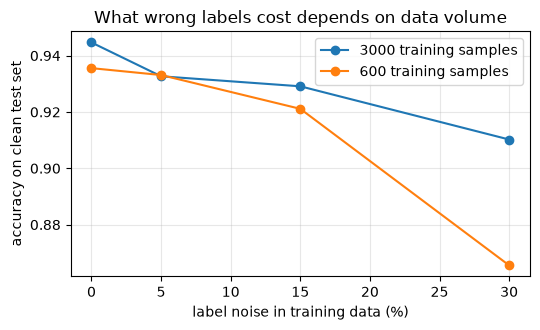

In [6]:
noise_levels = [0.0, 0.05, 0.15, 0.30]
regimes = {"3000 training samples": 3000, "600 training samples": 600}
sweep = {}
for name, n in regimes.items():
    curve = []
    for p in noise_levels:
        accs = []
        for s in [1, 2, 3]:
            data = make_data(n_train=n, label_noise=p, seed=s)
            torch.manual_seed(s)
            model = MLP(width=128, depth=2)
            train_model(model, data, epochs=50, batch_size=128, seed=s)
            accs.append(accuracy(model, *data[4:6]))
        curve.append(np.mean(accs))
        print(f"n={n:4d}  label noise {p:4.0%}  ->  clean-test accuracy {curve[-1]:.3f}")
    sweep[name] = curve

plt.figure(figsize=(5.5, 3.4))
for name, curve in sweep.items():
    plt.plot(np.array(noise_levels) * 100, curve, "o-", label=name)
plt.xlabel("label noise in training data (%)")
plt.ylabel("accuracy on clean test set")
plt.legend(); plt.grid(alpha=0.3); plt.title("What wrong labels cost depends on data volume")
plt.tight_layout()

Two regimes, two stories. With 3000 training samples, even 30% of randomly flipped labels costs little: cross-entropy averages over many samples, the flips are symmetric, and the correct majority still pins down the class boundaries. With 600 samples the same model has enough capacity to memorize the flipped labels instead of averaging them away, and accuracy falls several points. Label noise is most dangerous exactly where geoscience usually lives: small labeled datasets and models large enough to memorize them.

**What to look for in real data.** Validation accuracy that plateaus below what the class overlap suggests is a label-quality symptom, not an architecture problem. To detect it: inspect the samples the model gets most confidently "wrong" (they are often mislabeled, not misclassified), have a second analyst relabel a random subset and measure agreement, and cross-check labels against independent catalogs. And remember the noise that does the damage in practice is rarely symmetric: an analyst who systematically confuses two signal types biases the boundary itself, which is far worse than random flips. Fixing a thousand labels usually beats adding a million parameters.

### 3.2 Class imbalance

Andesite is already the rare class. We now shrink it further and watch per-class recall, not overall accuracy.

               overall acc  recall granite  recall basalt  recall andesite
minority kept                                                             
1.00                 0.946           0.972          0.967            0.735
0.50                 0.949           0.984          0.975            0.677
0.20                 0.915           0.984          0.981            0.329
0.05                 0.881           0.984          0.981            0.000


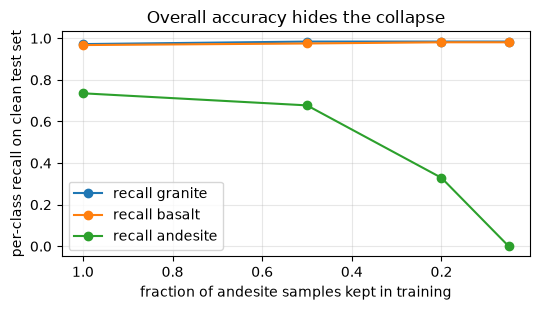

In [7]:
keep_fractions = [1.0, 0.5, 0.2, 0.05]
rows = []
for keep in keep_fractions:
    data = make_data(minority_keep=keep, seed=2)
    torch.manual_seed(2)
    model = MLP(width=32, depth=2)
    train_model(model, data, epochs=25, seed=2)
    Xte, yte = data[4], data[5]
    model.eval()
    with torch.no_grad():
        pred = model(Xte.to(device)).argmax(1).cpu().numpy()
    rec = recall_score(yte.numpy(), pred, average=None, labels=[0, 1, 2])
    rows.append({"minority kept": keep, "overall acc": (pred == yte.numpy()).mean(),
                 **{f"recall {c}": r for c, r in zip(CLASSES, rec)}})

imbalance = pd.DataFrame(rows).set_index("minority kept")
print(imbalance.round(3))

imbalance[[f"recall {c}" for c in CLASSES]].plot(marker="o", figsize=(5.5, 3.2))
plt.xlabel("fraction of andesite samples kept in training")
plt.ylabel("per-class recall on clean test set")
plt.grid(alpha=0.3); plt.gca().invert_xaxis()
plt.title("Overall accuracy hides the collapse")
plt.tight_layout()

Read the two columns against each other. Overall accuracy drifts down a few points — nothing alarming on a dashboard. Andesite recall collapses to zero: the model has stopped predicting the class entirely. Notice also that even at full data the rare class starts disadvantaged (recall 0.74 against 0.97 for the majority classes). This is the most common silent failure in geoscience classification, where the rare class (the eruption, the induced event, the landslide) is the one you care about.

**What to look for in real data.** Always report the full confusion matrix and per-class recall; never accuracy alone. If the minority class matters, use class weights in the loss, oversample it, or generate augmented minority examples — and check that the fix shows up in recall, not just in the loss.

### 3.3 Sensor noise on the features

Now the labels are right but the instrument degrades: we add extra Gaussian noise to the training and validation features, on top of the shared 1.0$\sigma$ measurement floor, in units of one feature standard deviation. The test set keeps the normal floor — this simulates training on data from a worse sensor than the one you deploy.

extra sensor noise 0.0 sigma  ->  clean-test accuracy 0.950


extra sensor noise 2.0 sigma  ->  clean-test accuracy 0.928


extra sensor noise 4.0 sigma  ->  clean-test accuracy 0.876


extra sensor noise 8.0 sigma  ->  clean-test accuracy 0.785


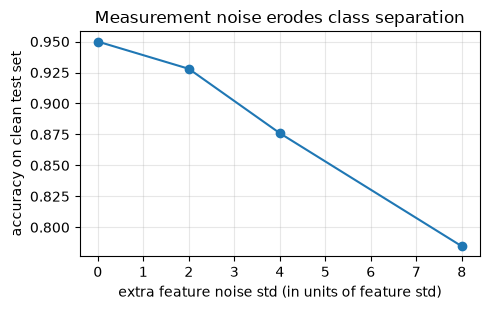

In [8]:
sensor_levels = [0.0, 2.0, 4.0, 8.0]
sensor_accs = []
for s in sensor_levels:
    data = make_data(feature_noise=s, seed=3)
    torch.manual_seed(3)
    model = MLP(width=64, depth=2)
    train_model(model, data, epochs=25, seed=3)
    sensor_accs.append(accuracy(model, *data[4:6]))
    print(f"extra sensor noise {s:.1f} sigma  ->  clean-test accuracy {sensor_accs[-1]:.3f}")

plt.figure(figsize=(5, 3.2))
plt.plot(sensor_levels, sensor_accs, "o-")
plt.xlabel("extra feature noise std (in units of feature std)")
plt.ylabel("accuracy on clean test set")
plt.grid(alpha=0.3); plt.title("Measurement noise erodes class separation")
plt.tight_layout()

Once the added noise reaches a few times the natural spread of each feature, the class clusters smear into each other and accuracy slides toward chance. No model recovers separation that the measurements no longer contain — this is the irreducible-error term of Section 2.5 made visible.

**What to look for in real data.** Estimate measurement uncertainty per feature (repeat measurements, instrument specifications, calibration records) and compare it against the between-class separation of that feature. Features whose noise exceeds their class separation add no signal; cleaning or dropping them is data curation, not defeat.

### 3.4 How much data is enough?

The classic learning-curve diagnostic plots performance against training-set size. This is the function to reuse whenever someone asks "would more data help?" — a question better measured than debated.

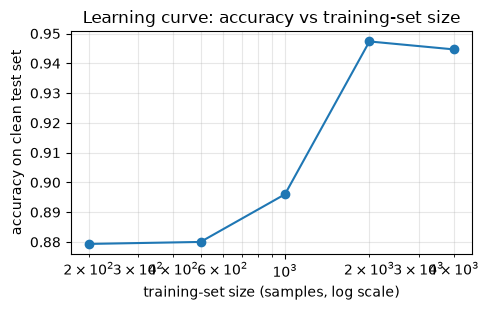

In [9]:
def plot_learning_curves(sizes, width=32, depth=2, epochs=25, seed=4):
    '''Test accuracy as a function of training-set size (Pillar 1 diagnostic).'''
    accs = []
    for n in sizes:
        data = make_data(n_train=n, seed=seed)
        torch.manual_seed(seed)
        model = MLP(width=width, depth=depth)
        train_model(model, data, epochs=epochs, seed=seed)
        accs.append(accuracy(model, *data[4:6]))
    plt.figure(figsize=(5, 3.2))
    plt.semilogx(sizes, accs, "o-")
    plt.xlabel("training-set size (samples, log scale)")
    plt.ylabel("accuracy on clean test set")
    plt.grid(alpha=0.3, which="both")
    plt.title("Learning curve: accuracy vs training-set size")
    plt.tight_layout()
    return accs

sizes = [200, 500, 1000, 2000, 4000]
accs_vs_size = plot_learning_curves(sizes)

The curve rises steeply, then flattens: past a few thousand samples, more identical data buys little. If the curve is still rising at your current data size, collect more data before tuning anything else. If it has flattened, more of the same data will not help; better labels, better features, or harder examples might.

## 4. Pillar 2 — Architecture

With the data held clean and fixed, we now vary the model. The questions are always the same: how wide, how deep, and compared to what baseline?

### 4.1 Width

   width  params  test acc
0      4      75  0.852000
1     16     483  0.882667
2     64    4995  0.951333
3    256   69123  0.949333


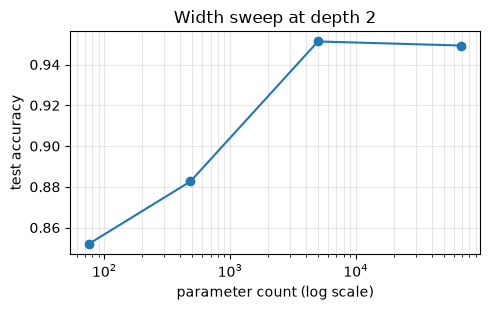

In [10]:
data = make_data(seed=5)

widths = [4, 16, 64, 256]
rows = []
for w in widths:
    torch.manual_seed(5)
    model = MLP(width=w, depth=2)
    train_model(model, data, epochs=25, seed=5)
    rows.append({"width": w, "params": count_params(model),
                 "test acc": accuracy(model, *data[4:6])})
width_sweep = pd.DataFrame(rows)
print(width_sweep)

plt.figure(figsize=(5, 3.2))
plt.semilogx(width_sweep["params"], width_sweep["test acc"], "o-")
plt.xlabel("parameter count (log scale)")
plt.ylabel("test accuracy")
plt.grid(alpha=0.3, which="both"); plt.title("Width sweep at depth 2")
plt.tight_layout()

Accuracy saturates within a factor of a few of the smallest adequate width. Past that point, parameters are free in accuracy but not in training time, memory, or overfitting risk on smaller datasets.

### 4.2 Depth at a fixed parameter budget

Is it better to spend a fixed parameter budget on depth or width? We solve for the width that gives each depth roughly the same parameter count, then compare.

In [11]:
def width_for_budget(depth, budget=5000):
    '''Smallest width whose MLP meets or exceeds the parameter budget.'''
    for w in range(1, 1024):
        if count_params(MLP(width=w, depth=depth)) >= budget:
            return w
    return 1024

rows = []
for d in [1, 2, 4]:
    w = width_for_budget(d)
    torch.manual_seed(6)
    model = MLP(width=w, depth=d)
    train_model(model, data, epochs=25, seed=6)
    rows.append({"depth": d, "width": w, "params": count_params(model),
                 "test acc": accuracy(model, *data[4:6])})
depth_sweep = pd.DataFrame(rows)
print(depth_sweep)

   depth  width  params  test acc
0      1    385    5008  0.952000
1      2     65    5138  0.954667
2      4     39    5190  0.950667


On a 9-feature tabular problem, depth buys little: the correlations the generator planted are low-order, and a shallow-but-wide network represents them as well as a deep one. Depth pays when the data has hierarchical structure — edges to textures to objects in images (notebook 4.3), samples to motifs to phrases in sequences (notebook 4.4). Match the architecture to the structure of the data, not to fashion.

### 4.3 The baseline you must always run

Every deep model needs a cheap reference point. For classification, that is multinomial logistic regression — equivalently, our MLP with depth 0 (a single linear layer plus softmax).

In [12]:
torch.manual_seed(7)
logistic = MLP(width=1, depth=0)     # depth=0 -> a single linear layer
train_model(logistic, data, epochs=25, seed=7)
torch.manual_seed(7)
best_mlp = MLP(width=64, depth=2)
train_model(best_mlp, data, epochs=25, seed=7)

print(f"logistic baseline ({count_params(logistic):5d} params): "
      f"test acc {accuracy(logistic, *data[4:6]):.3f}")
print(f"MLP 64x2          ({count_params(best_mlp):5d} params): "
      f"test acc {accuracy(best_mlp, *data[4:6]):.3f}")

logistic baseline (   30 params): test acc 0.879
MLP 64x2          ( 4995 params): test acc 0.953


The gap is real but modest — typical for well-behaved tabular data. If your deep model cannot beat the linear baseline, the problem is the data or the features, not a missing layer. Report the baseline in every project; it is the honest denominator for every claim about deep learning.

### 4.4 Deep ensembles: uncertainty from disagreement

Train the same architecture from several random seeds and the runs converge to different functions that agree on easy samples and disagree near class boundaries. That disagreement is a practical, well-calibrated uncertainty estimate (Lakshminarayanan et al., 2017, *NeurIPS*), and it costs nothing but repeated training.

In [13]:
n_members = 5
member_probs, member_accs = [], []
Xte, yte = data[4], data[5]
for s in range(n_members):
    torch.manual_seed(100 + s)                  # different init per member
    member = MLP(width=64, depth=2)
    train_model(member, data, epochs=25, seed=100 + s)  # different batches too
    member.eval()
    with torch.no_grad():
        probs = torch.softmax(member(Xte.to(device)), dim=1).cpu().numpy()
    member_probs.append(probs)
    member_accs.append(accuracy(member, Xte, yte))

member_probs = np.stack(member_probs)           # (members, samples, classes)
ens_mean = member_probs.mean(axis=0)
ens_pred = ens_mean.argmax(1)
ens_acc = (ens_pred == yte.numpy()).mean()
# disagreement: std across members of the probability of the ensemble's chosen class
ens_std = member_probs.std(axis=0)[np.arange(len(yte)), ens_pred]

print("member accuracies:", np.round(member_accs, 3))
print(f"ensemble-mean accuracy: {ens_acc:.3f}")

member accuracies: [0.952 0.949 0.951 0.949 0.949]
ensemble-mean accuracy: 0.949


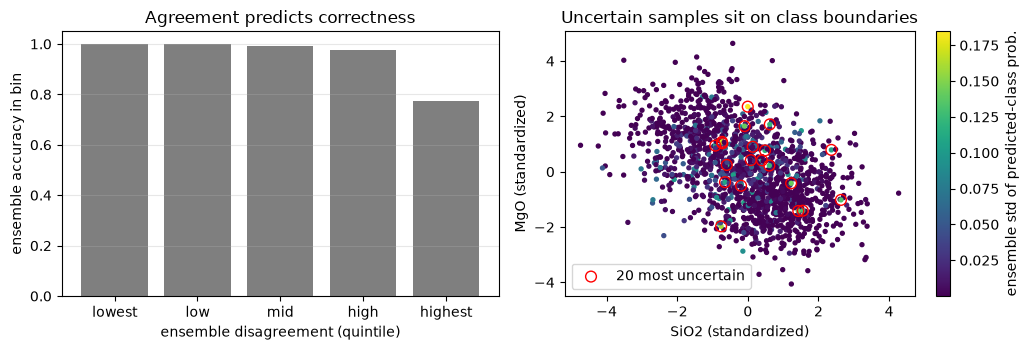

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))

# reliability/agreement plot: accuracy within quintiles of ensemble disagreement
bins = np.quantile(ens_std, np.linspace(0, 1, 6))
bin_idx = np.clip(np.digitize(ens_std, bins[1:-1]), 0, 4)
correct = ens_pred == yte.numpy()
bin_acc = [correct[bin_idx == b].mean() for b in range(5)]
ax[0].bar(range(5), bin_acc, color="tab:gray")
ax[0].set_xticks(range(5))
ax[0].set_xticklabels(["lowest", "low", "mid", "high", "highest"])
ax[0].set_xlabel("ensemble disagreement (quintile)")
ax[0].set_ylabel("ensemble accuracy in bin")
ax[0].set_title("Agreement predicts correctness")
ax[0].grid(alpha=0.3, axis="y")

# where the uncertain samples live in feature space
sio2 = Xte[:, FEATURES.index("SIO2")].numpy()
mgo = Xte[:, FEATURES.index("MGO")].numpy()
sc = ax[1].scatter(sio2, mgo, c=ens_std, s=8, cmap="viridis")
flag = np.argsort(ens_std)[-20:]                # 20 most uncertain samples
ax[1].scatter(sio2[flag], mgo[flag], facecolors="none",
              edgecolors="red", s=60, label="20 most uncertain")
plt.colorbar(sc, ax=ax[1], label="ensemble std of predicted-class prob.")
ax[1].set_xlabel("SiO2 (standardized)"); ax[1].set_ylabel("MgO (standardized)")
ax[1].set_title("Uncertain samples sit on class boundaries")
ax[1].legend()
plt.tight_layout()

Two payoffs. First, the ensemble mean is usually at least as accurate as the best single member. Second — and more useful in practice — samples where the members disagree are exactly the samples the ensemble gets wrong most often, and they cluster along class boundaries in feature space. In a real workflow you would route the flagged samples to a human analyst. The final-project milestone offers this analysis as one of the two required uncertainty experiments.

## 5. Pillar 3 — Training strategies

Same data, same architecture: everything below changes only how we train.

### 5.1 The learning rate, three ways

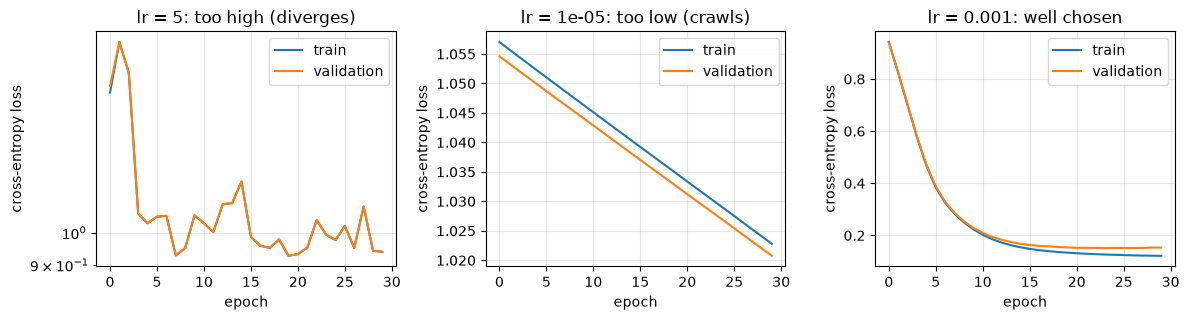

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.3), sharex=True)
for ax, (lr, label) in zip(axes, [(5.0, "too high (diverges)"),
                                  (1e-5, "too low (crawls)"),
                                  (1e-3, "well chosen")]):
    torch.manual_seed(8)
    model = MLP(width=32, depth=2)
    hist = train_model(model, data, epochs=30, lr=lr, optimizer="sgd"
                       if lr == 5.0 else "adam", seed=8)
    plot_history(hist, ax=ax, title=f"lr = {lr:g}: {label}", logy=(lr == 5.0))
plt.tight_layout()

Three signatures to memorize:

* **Too high**: the loss oscillates or explodes; each step overshoots the valley. (With unstable runs the loss can reach `inf` or `NaN`; the log axis makes the explosion readable.)
* **Too low**: both curves creep down a nearly straight line and training "works" but would need hundreds of epochs.
* **Well chosen**: fast early drop, then a smooth flattening.

When in doubt, sweep the learning rate in powers of 10 first. Nothing else in this section matters until this is roughly right.

### 5.2 Batch size

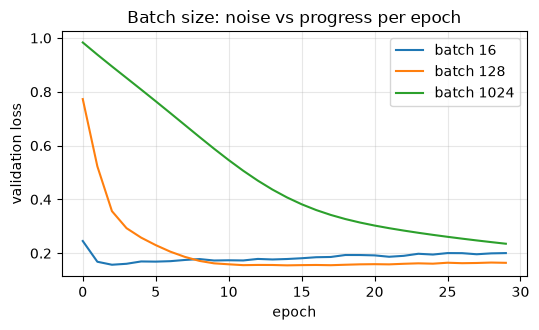

In [16]:
plt.figure(figsize=(5.5, 3.4))
for bs in [16, 128, 1024]:
    torch.manual_seed(9)
    model = MLP(width=32, depth=2)
    hist = train_model(model, data, epochs=30, batch_size=bs, seed=9)
    plt.plot(hist["val_loss"], label=f"batch {bs}")
plt.xlabel("epoch"); plt.ylabel("validation loss")
plt.legend(); plt.grid(alpha=0.3)
plt.title("Batch size: noise vs progress per epoch")
plt.tight_layout()

Small batches take many noisy steps per epoch: fast initial progress and a mild regularizing effect, at the price of jitter. Large batches take few smooth steps: each epoch does less, so at a fixed epoch budget the curve lags, and very large batches often generalize slightly worse. Batch size also sets memory use, which is what usually decides it on real hardware. The common practice: the largest batch that fits comfortably in memory, with the learning rate re-tuned when the batch changes.

### 5.3 Overfitting live, and early stopping

To force overfitting we give a large model a small, noisy training set and let it run long.

val loss at best epoch 15: 0.393
val loss at final epoch:  1.561


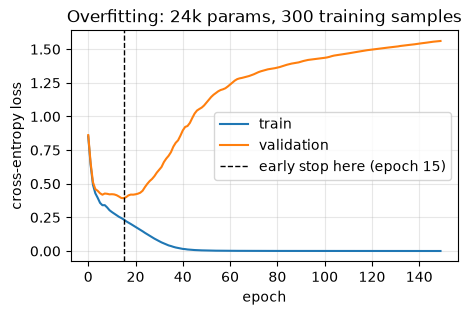

In [17]:
small_noisy = make_data(n_train=400, label_noise=0.10, seed=10)
torch.manual_seed(10)
big_model = MLP(width=256, depth=3)
hist_over = train_model(big_model, small_noisy, epochs=150, seed=10)

best_epoch = int(np.argmin(hist_over["val_loss"]))
ax = plot_history(hist_over, title="Overfitting: 24k params, 300 training samples")
ax.axvline(best_epoch, color="k", ls="--", lw=1,
           label=f"early stop here (epoch {best_epoch})")
ax.legend()
print(f"val loss at best epoch {best_epoch}: {hist_over['val_loss'][best_epoch]:.3f}")
print(f"val loss at final epoch:  {hist_over['val_loss'][-1]:.3f}")

The textbook signature: training loss falls toward zero while validation loss bottoms out and climbs. **Early stopping** regularizes by simply keeping the model from the epoch where validation loss was lowest. The standard implementation keeps a patience counter:

```python
best_val, patience, wait = float("inf"), 20, 0
for epoch in range(max_epochs):
    train_one_epoch(...)
    val = validation_loss(...)
    if val < best_val:
        best_val, wait = val, 0
        torch.save(model.state_dict(), "best.pt")   # checkpoint the best model
    else:
        wait += 1
        if wait > patience:
            break                                    # stop; reload best.pt
```

Notebook 4.2 covers the checkpointing half of this pattern.

### 5.4 Learning-rate schedulers

A schedule starts with a large learning rate for fast progress and shrinks it for a precise finish — a compromise between the "too high" and "too low" panels of Section 5.1.

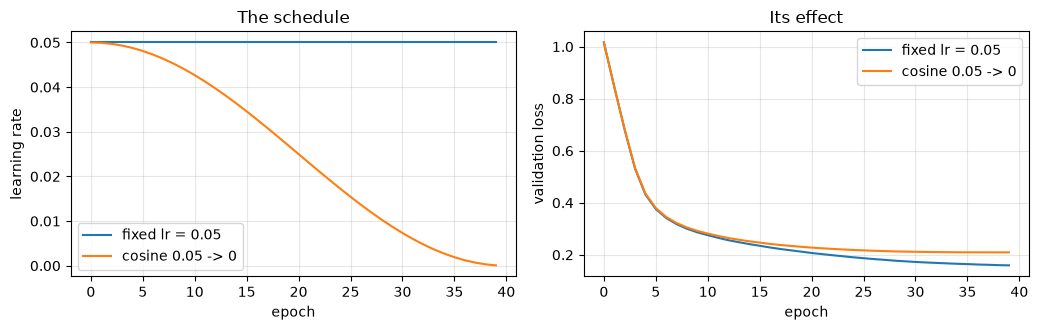

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4))
runs = {
    "fixed lr = 0.05": dict(lr=0.05, scheduler=None),
    "cosine 0.05 -> 0": dict(lr=0.05,
        scheduler=lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=40)),
}
for label, kw in runs.items():
    torch.manual_seed(11)
    model = MLP(width=32, depth=2)
    hist = train_model(model, data, epochs=40, optimizer="sgd", seed=11, **kw)
    ax[0].plot(hist["lr"], label=label)
    ax[1].plot(hist["val_loss"], label=label)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("learning rate")
ax[0].set_title("The schedule"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("validation loss")
ax[1].set_title("Its effect"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()

`StepLR` (drop the rate by a factor every $k$ epochs) and cosine annealing are the two schedules you will meet most often. On a problem this small the gain is modest; on large models, schedules are standard practice.

### 5.5 Exercise: diagnose six broken training runs

Below are learning curves from six training runs, each broken in a different way (or suspicious in a different way). The pathologies, in shuffled order: learning rate too high, learning rate too low, overfitting, underfitting (not enough capacity), heavy label noise, and data leakage into the validation set.

Diagnose each run from its curves **before** reading the generation code above the figure or opening the solution.

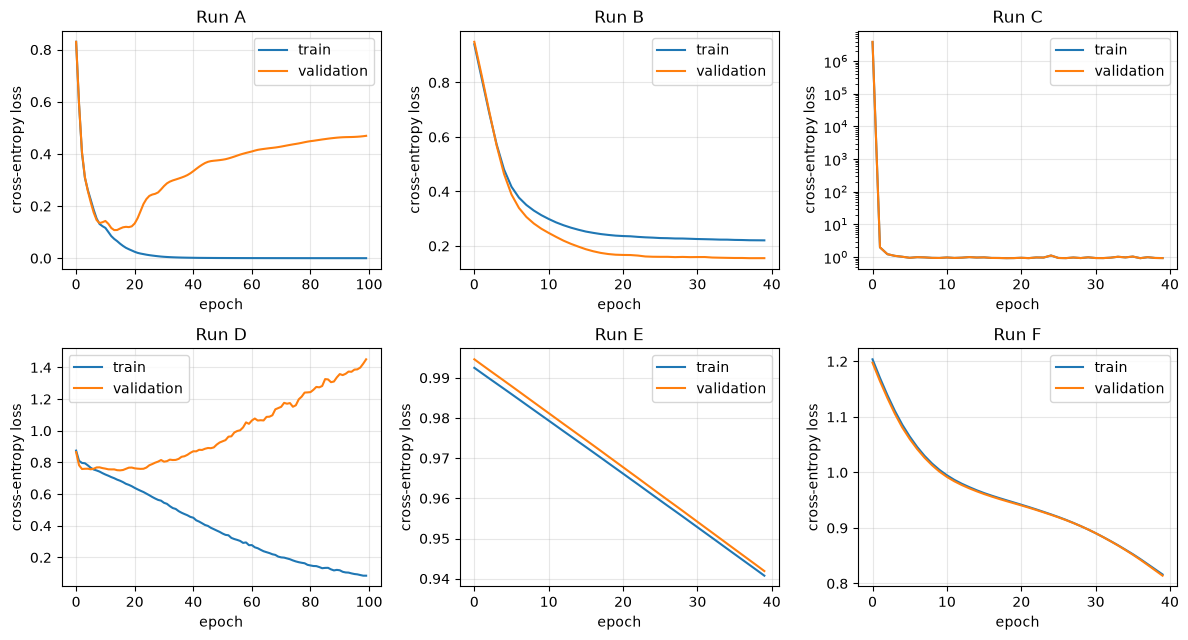

In [19]:
def make_broken_runs():
    '''Six rigged training runs. Diagnose from the curves before reading this.'''
    runs = {}
    d = make_data(seed=20)
    torch.manual_seed(20)
    runs["high_lr"] = train_model(MLP(32, 2), d, epochs=40, lr=5.0,
                                  optimizer="sgd", seed=20)
    torch.manual_seed(21)
    runs["low_lr"] = train_model(MLP(32, 2), d, epochs=40, lr=1e-5, seed=21)
    torch.manual_seed(22)
    runs["overfit"] = train_model(MLP(256, 3), make_data(n_train=400, seed=22),
                                  epochs=100, seed=22)
    torch.manual_seed(23)
    runs["underfit"] = train_model(MLP(1, 1), d, epochs=40, seed=23)   # width-1 bottleneck
    torch.manual_seed(24)
    runs["label_noise"] = train_model(MLP(256, 2),
                                      make_data(n_train=800, label_noise=0.35, seed=24),
                                      epochs=100, seed=24)
    # leakage-style pathology: training inputs get heavy augmentation noise,
    # validation stays pristine -> validation beats training throughout
    d_leak = list(make_data(seed=25))
    rng = np.random.default_rng(25)
    d_leak[0] = d_leak[0] + torch.as_tensor(
        rng.normal(0, 0.8, d_leak[0].shape), dtype=torch.float32)
    torch.manual_seed(25)
    runs["leakage"] = train_model(MLP(32, 2), tuple(d_leak), epochs=40, seed=25)
    return runs

broken = make_broken_runs()
display_order = ["overfit", "leakage", "high_lr", "label_noise", "low_lr", "underfit"]
letters = "ABCDEF"

fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
for ax, letter, key in zip(axes.ravel(), letters, display_order):
    plot_history(broken[key], ax=ax, title=f"Run {letter}",
                 logy=(max(broken[key]["train_loss"]) > 10))
plt.tight_layout()

For each run, write down: the pathology, the evidence in the curves, and the fix you would try first.

```{admonition} Solution
:class: dropdown

**Run A — overfitting.** Training loss falls toward zero while validation loss bottoms out early and climbs steadily. A 24k-parameter model saw only 300 training samples. Fix: more data, a smaller model, regularization, or early stopping at the validation minimum.

**Run B — data leakage (or train-only augmentation).** Validation loss sits *below* training loss for the whole run. Genuine validation data is never systematically easier than training data; when validation wins, suspect that validation samples leaked into training, that the split duplicated near-identical samples across the boundary, or that noise/augmentation was applied to the training inputs only (the actual cause here). Fix: audit the split before believing the numbers.

**Run C — learning rate too high.** The loss explodes within a few epochs (note the log axis) instead of decreasing. Steps overshoot the minimum and diverge. Fix: drop the learning rate by 10x-100x and re-run.

**Run D — heavy label noise.** Training loss keeps sinking as the oversized model memorizes flipped labels, while validation loss quickly reaches a floor and stays there — it plateaus rather than climbing sharply, and validation accuracy is capped far below what the features support. Distinguishing this from overfitting takes care: with label noise, no amount of regularization raises the validation ceiling. Fix: audit and clean the labels (Section 3.1).

**Run E — learning rate too low.** Both curves descend a shallow, nearly straight line and are still far from converged after 40 epochs. Nothing is wrong except patience. Fix: raise the learning rate by 10x-100x.

**Run F — underfitting.** Both curves plateau almost immediately at a high loss with a tiny train-validation gap. The width-1 network cannot represent the class boundaries. Fix: increase capacity (width/depth) or engineer better features.
```

### 5.6 Hyperparameter search with Optuna

After the manual sweeps, the systematic version. [Optuna](https://optuna.org/) samples hyperparameter combinations, observes the validation score of each trial, and focuses the search where scores are good. Twenty trials on our small task take under a minute.

best validation accuracy: 0.928
best hyperparameters: {'lr': 0.024973286104060587, 'width': 32, 'dropout': 0.0716766437045232, 'weight_decay': 0.0060072494759062}


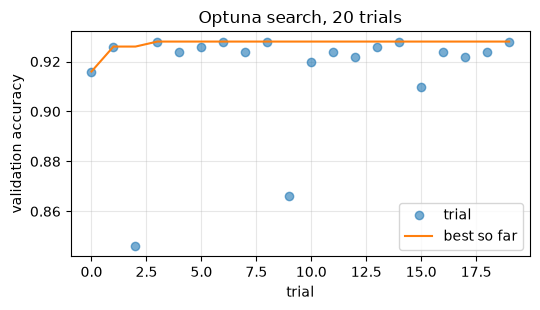

In [20]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

data_opt = make_data(n_train=2000, seed=30)

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    width = trial.suggest_categorical("width", [16, 32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    torch.manual_seed(31)
    model = MLP(width=width, depth=2, dropout=dropout)
    hist = train_model(model, data_opt, epochs=12, lr=lr,
                       weight_decay=weight_decay, seed=31)
    return max(hist["val_acc"])

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(objective, n_trials=20)

print("best validation accuracy:", round(study.best_value, 3))
print("best hyperparameters:", study.best_params)

trial_vals = [t.value for t in study.trials]
plt.figure(figsize=(5.5, 3.2))
plt.plot(trial_vals, "o", alpha=0.6, label="trial")
plt.plot(np.maximum.accumulate(trial_vals), "-", label="best so far")
plt.xlabel("trial"); plt.ylabel("validation accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.title("Optuna search, 20 trials")
plt.tight_layout()

Search the hyperparameters that Section 5 showed matter — learning rate first, then regularization and width — over ranges your manual sweeps found sensible. Always keep the final test set out of the search: Optuna optimizes the validation score, and the test set is spent only once at the end.

### 5.7 Why architecture search stopped mattering

Ten years ago, neural architecture search — algorithms that design network wiring automatically — was an active research front. It has largely faded, for a simple reason: a handful of canonical architectures (the MLP, the convolutional network, the transformer) plus scale won. In domain after domain, taking a standard architecture and spending the compute on more data, more parameters, and better training beat bespoke wiring discovered by search. What remains of the search problem moved to where you just practiced it: hyperparameters (Optuna and its relatives) and, above all, the data pillar. This is also the practical advice for your projects: pick the canonical architecture that matches your data's structure, then spend your effort on data curation and training diagnostics.

## 6. Checklist for training a deep learning model

1. **Characterize the data** (Chapter 2): dimensionality, units, correlations, class balance.
2. **Set aside the test data** first. Consider causality and independence between test and training samples: random splits leak when samples are correlated in time or space.
3. **Curate the training data** (Pillar 1): audit labels, quantify measurement noise, check per-class counts, and diversify with augmentation where physical transformations make sense.
4. **Design the network** (Pillar 2): match the architecture family to the structure of the data, start small, and always include the linear or classical-ML baseline.
5. **Define the loss** appropriate to the task and the domain objectives (Section 2), consulting the [PyTorch loss-function documentation](https://pytorch.org/docs/stable/nn.html#loss-functions) and [scikit-learn metrics](https://scikit-learn.org/stable/modules/model_evaluation.html).
6. **Choose the optimizer and training strategy** (Pillar 3): Adam as a default, learning rate swept in powers of ten, the largest comfortable batch, a scheduler for longer runs.
7. **Train with diagnostics on**: record training and validation curves every run, checkpoint the best validation model, early-stop when validation stalls.
8. **Evaluate honestly**: per-class metrics, the untouched test set once, and an uncertainty estimate (a deep ensemble if you can afford five runs).

## 7. Summary

You now have a diagnostic vocabulary attached to curves you have generated yourself: what label noise, class imbalance, and sensor noise cost (Pillar 1); how width, depth, baselines, and ensembles behave (Pillar 2); and what learning rate, batch size, overfitting, early stopping, and schedulers look like in learning curves (Pillar 3). The six broken runs of Section 5.5 are the exam that real projects will keep administering.

Apply this lab to your own project: for the final-project milestone you will reuse the sweep patterns on your architectures, keep a diagnostics appendix with at least one failed run, and run either the deep-ensemble analysis from Section 4.4 or the fine-tuning experiment from notebook 4.6.